In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
pd.options.display.float_format = "{:,.2f}".format

In [ ]:
df = pd.read_parquet(
    "../data/processed/v2/housing_residential_processed.parquet"
).copy()

In [4]:
df.iloc[0]

address                   Коммунистическая, д. 26
longitude                                   37.58
latitude                                    55.51
area                                        44.70
room_count                                      2
floor                                           2
floor_count                                     5
market_type                             secondary
flat_type                                    flat
ceiling_height                                NaN
build_year                                   <NA>
balcony                                     False
price                                3,500,000.00
price_per_square_meter                  78,299.80
date                          2025-06-09 00:00:00
Name: 0, dtype: object

In [ ]:
df[["price", "price_per_square_meter"]].describe()

,price,price_per_square_meter
count,"1,336,403.00","1,336,403.00"
mean,"11,277,568.91","213,595.24"
std,"17,980,683.52","140,326.39"
min,"1,100,000.00","4,239.10"
25%,"5,400,000.00","123,598.00"
50%,"8,009,999.92","183,000.00"
75%,"12,614,026.88","260,805.12"
max,"5,306,441,010.50","8,925,889.00"


In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year

df_year_max = df.groupby(["year", "market_type"], as_index=False).agg(
    max_price=("price", "max")
)

df_year_max

,year,market_type,max_price
0,2004,primary,"4,730,810.00"
1,2007,primary,"9,486,714.10"
2,2009,primary,"10,887,230.70"
3,2010,secondary,"8,120,000.00"
4,2011,secondary,"33,000,000.00"
5,2012,secondary,"8,600,000.00"
6,2013,primary,"14,900,671.22"
7,2013,secondary,"34,115,000.00"
8,2014,primary,"8,851,875.90"
9,2014,secondary,"15,000,000.00"


Хотим прежде чем применять какую-то функцию дисконта сперва посмотреть - как вообще выглядит распределение данных, в частности, построим график изменения **максимальной** стоимости квартир за вест период.

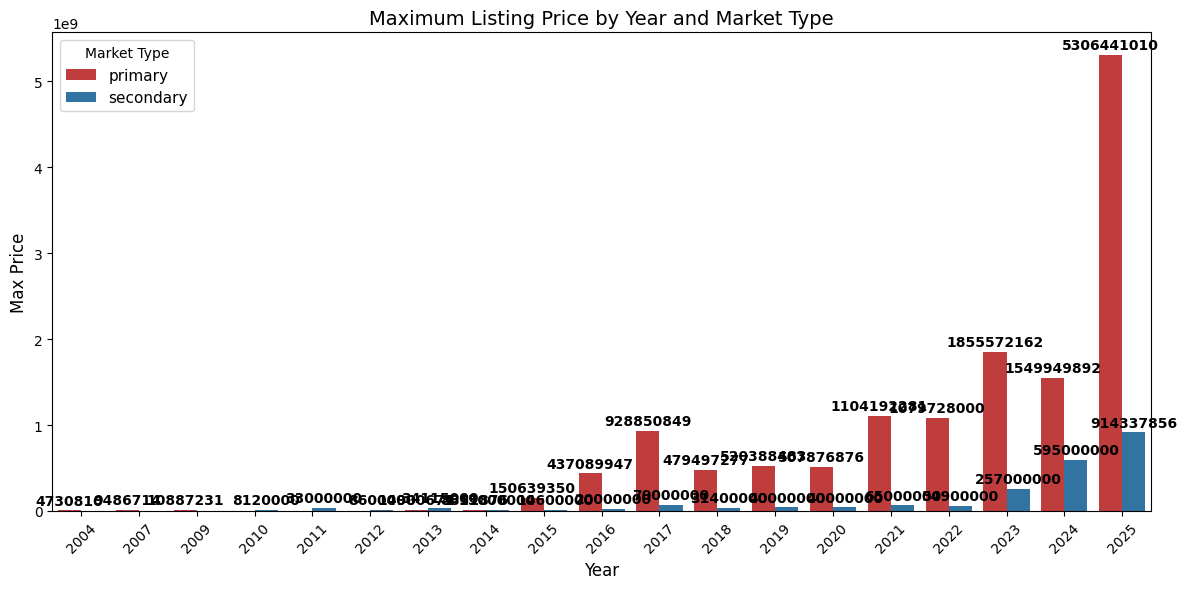

In [ ]:
# The histogram
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_year_max,
    x="year",
    y="max_price",
    hue="market_type",
    palette={"primary": "#d62728", "secondary": "#1f77b4"},
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2, fontsize=10, fontweight="bold")

plt.title("Maximum Listing Price by Year and Market Type", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Max Price", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Market Type", fontsize=11)
plt.tight_layout()
plt.show()

Зафиксировали какое-то понимание, выводы из этого графика делать не будем

In [ ]:
df_year_min = df.groupby(["year", "market_type"], as_index=False).agg(
    min_price=("price", "min")
)

df_year_min

,year,market_type,min_price
0,2004,primary,"4,730,810.00"
1,2007,primary,"8,156,780.80"
2,2009,primary,"8,156,780.80"
3,2010,secondary,"5,600,000.00"
4,2011,secondary,"4,200,000.00"
5,2012,secondary,"3,050,000.00"
6,2013,primary,"2,511,144.88"
7,2013,secondary,"3,600,000.00"
8,2014,primary,"2,547,035.70"
9,2014,secondary,"2,380,000.00"


Аналогично построим график изменения **минимальной** цены за квартиру за все года

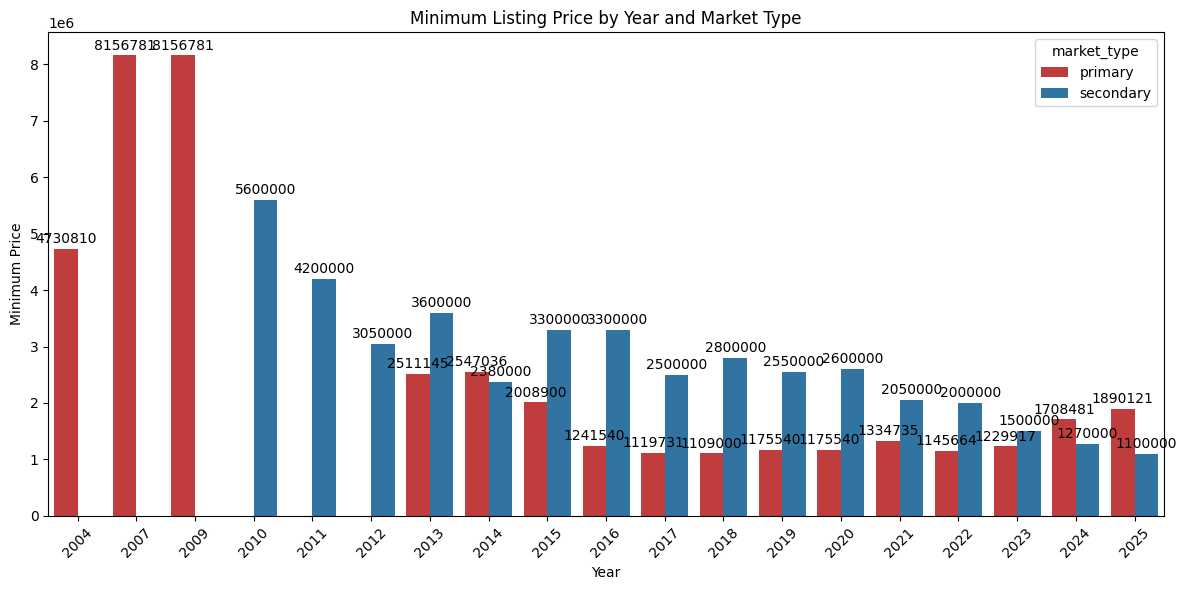

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_year_min,
    x="year",
    y="min_price",
    hue="market_type",
    palette={"primary": "#d62728", "secondary": "#1f77b4"},
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Minimum Listing Price by Year and Market Type")
plt.xlabel("Year")
plt.ylabel("Minimum Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Занятно, что в то время, как из года в год максимальная цена за квартиру увеличивается, минимальная цена - уменьшается. Возможно, в данных есть какие-то неточные или ошибочные значения (в частности, Павел Игоревич говорил о наборе квартир в центре Москвы, покупка которых осуществляется по какому-то странному договору, где взнос равен половине цены, при этом не учитывается в самой цене, а сама цена еще разбита на платежи, и в общем квартира в центр Москвы стоит 100 тысяч, и из таких квартир целый дом состоит, стоит посмотреть на данные еще раз и вырезать эти ошибки)

In [ ]:
df_year_mean = (
    df.groupby(["year", "market_type"]).agg(mean_price=("price", "mean")).reset_index()
)

df_year_mean

,year,market_type,mean_price
0,2004,primary,"4,730,810.00"
1,2007,primary,"8,821,747.45"
2,2009,primary,"8,929,742.11"
3,2010,secondary,"6,906,666.67"
4,2011,secondary,"11,248,625.00"
5,2012,secondary,"5,413,333.33"
6,2013,primary,"6,941,694.99"
7,2013,secondary,"11,554,347.83"
8,2014,primary,"4,884,051.48"
9,2014,secondary,"5,588,181.82"


Ну и посмотрим, как изменяется средняя цена за квартиру.

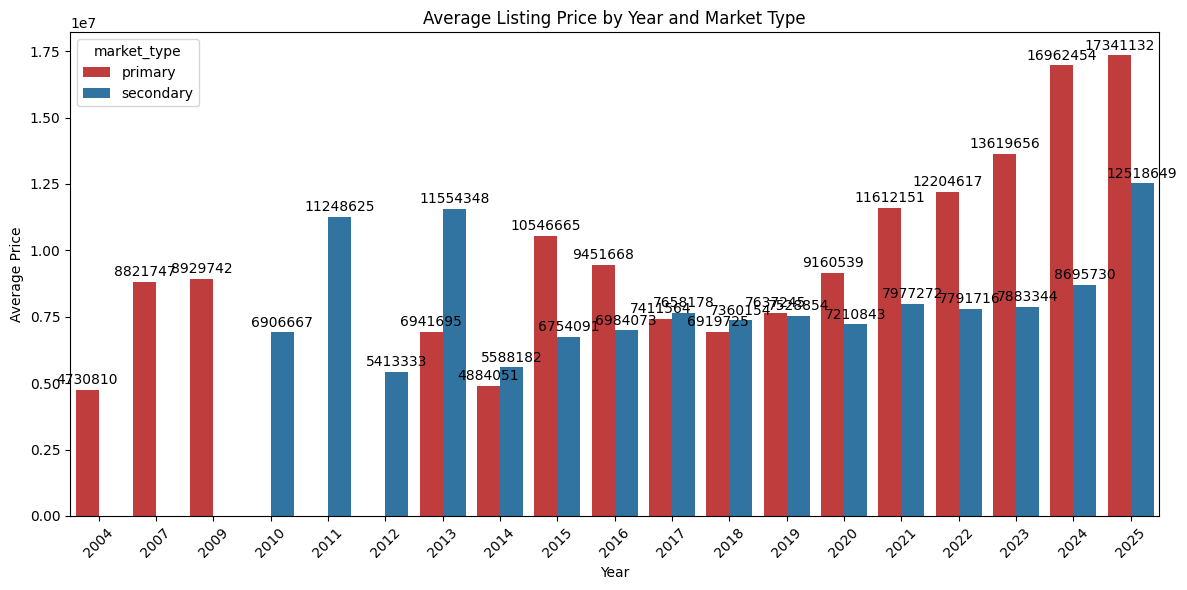

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_year_mean,
    x="year",
    y="mean_price",
    hue="market_type",
    palette={"primary": "#d62728", "secondary": "#1f77b4"},
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Average Listing Price by Year and Market Type")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_year_ppsqm = df.groupby(["year", "market_type"], as_index=False).agg(
    max_ppsqm=("price_per_square_meter", "max"),
    min_ppsqm=("price_per_square_meter", "min"),
    mean_ppsqm=("price_per_square_meter", "mean"),
)

Аналогичные рассуждения для цены за квадратный метр

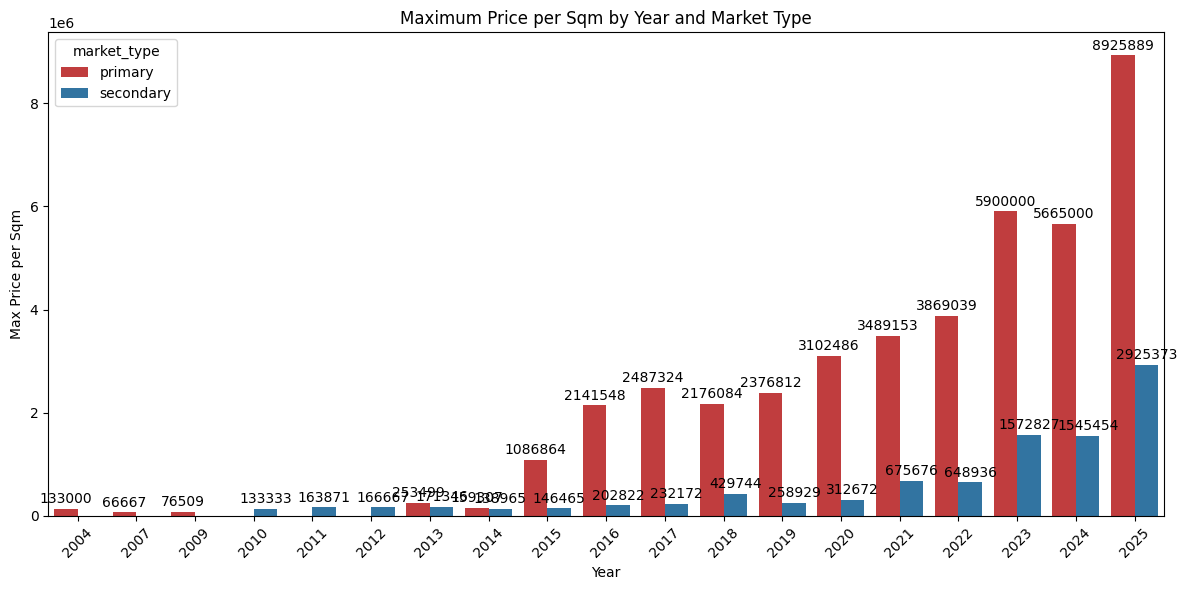

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_year_ppsqm,
    x="year",
    y="max_ppsqm",
    hue="market_type",
    palette={"primary": "#d62728", "secondary": "#1f77b4"},
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Maximum Price per Sqm by Year and Market Type")
plt.xlabel("Year")
plt.ylabel("Max Price per Sqm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

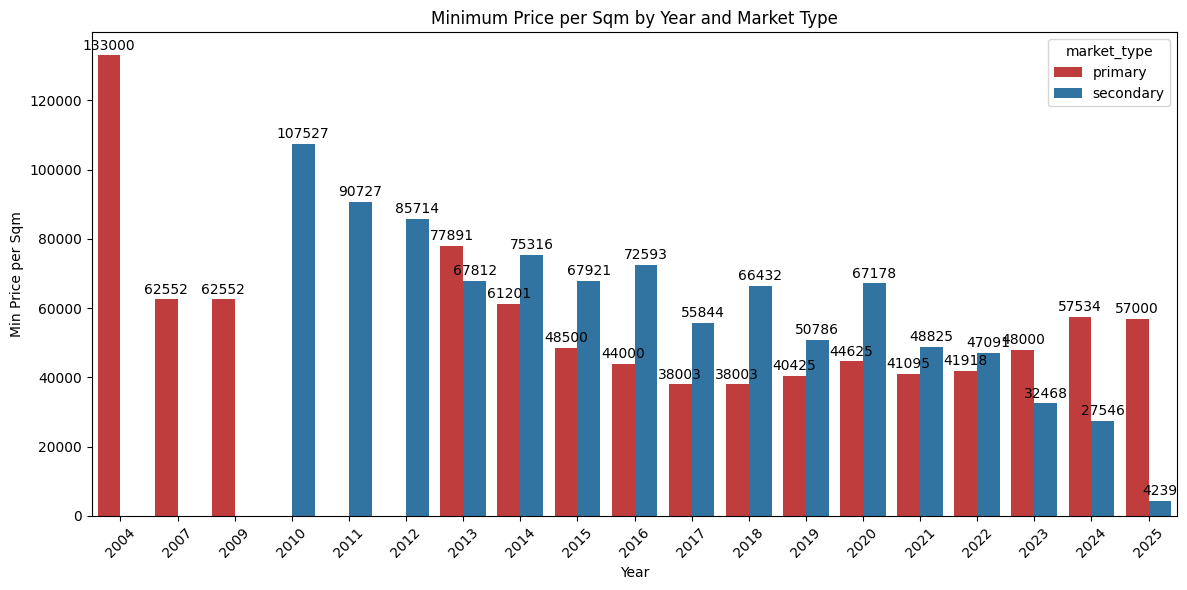

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_year_ppsqm,
    x="year",
    y="min_ppsqm",
    hue="market_type",
    palette={"primary": "#d62728", "secondary": "#1f77b4"},
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Minimum Price per Sqm by Year and Market Type")
plt.xlabel("Year")
plt.ylabel("Min Price per Sqm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

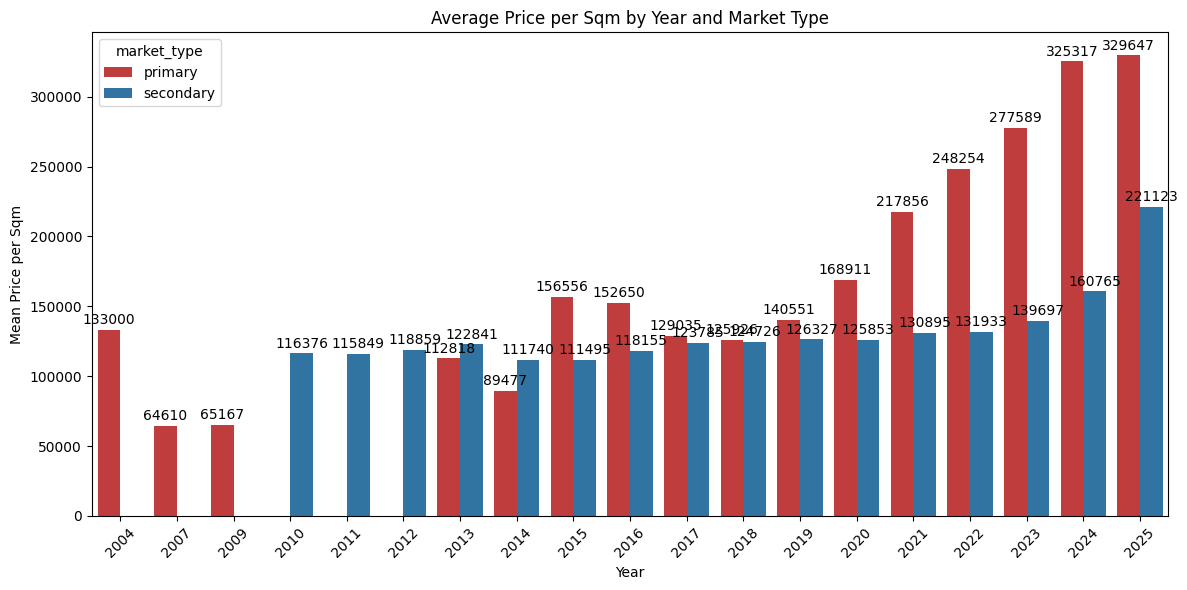

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_year_ppsqm,
    x="year",
    y="mean_ppsqm",
    hue="market_type",
    palette={"primary": "#d62728", "secondary": "#1f77b4"},
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Average Price per Sqm by Year and Market Type")
plt.xlabel("Year")
plt.ylabel("Mean Price per Sqm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Соберем статистику по ценам за месяцам, а затем каждому месяцу сопоставим среднюю цену за жилье (здесь учитывается как первичка, так и вторичка)

In [ ]:
df["year_month"] = df["date"].dt.to_period("M")

monthly_stats = df.groupby("year_month", as_index=False).agg(
    mean_price=("price", "mean")
)
monthly_stats

,year_month,mean_price
0,2004-04,"4,730,810.00"
1,2007-10,"8,821,747.45"
2,2009-06,"9,009,518.65"
3,2009-10,"8,821,747.45"
4,2009-11,"8,997,665.51"
...,...,...
165,2025-04,"13,181,510.71"
166,2025-05,"12,735,857.99"
167,2025-06,"13,312,651.01"
168,2025-07,"17,580,916.47"


Суть дисконта заключается в следующем:

1) Выберем "базовый месяц", пусть, к примеру, этим месяцом будет последний из данных. Назовем его $P_{base}$.
2) Вычислим для каждого месяца "индекс дисконта" $I_t = \frac{P_t}{P_{base}}$.
3) Соответственно теперь можно среднюю стоимость каждого месяца привести к ценам "сегодняшего дня", а точнее, к ценам того месяца, который мы выбрали как базисный: $$P^{new}_{t} = \frac{P_t}{I_t}$$

In [ ]:
base_value = monthly_stats["mean_price"].iloc[-1]

monthly_stats["index"] = monthly_stats["mean_price"] / base_value

print(f"base_value = {base_value} \n")
print("Index")
print(monthly_stats["index"])
monthly_stats

base_value = 50066307.754999995 

Index
0     0.09
1     0.18
2     0.18
3     0.18
4     0.18
      ... 
165   0.26
166   0.25
167   0.27
168   0.35
169   1.00
Name: index, Length: 170, dtype: float64


,year_month,mean_price,index
0,2004-04,"4,730,810.00",0.09
1,2007-10,"8,821,747.45",0.18
2,2009-06,"9,009,518.65",0.18
3,2009-10,"8,821,747.45",0.18
4,2009-11,"8,997,665.51",0.18
...,...,...,...
165,2025-04,"13,181,510.71",0.26
166,2025-05,"12,735,857.99",0.25
167,2025-06,"13,312,651.01",0.27
168,2025-07,"17,580,916.47",0.35


In [ ]:
df = df.merge(monthly_stats[["year_month", "index"]], on="year_month", how="left")

Вычислим "реальную цену" для каждого месяца, используя столбец цен и столбец индексов.

In [ ]:
df["price_real"] = df["price"] / df["index"]

График **средних** цен по первичке и вторичке до нормализации:

<Axes: xlabel='year_month'>

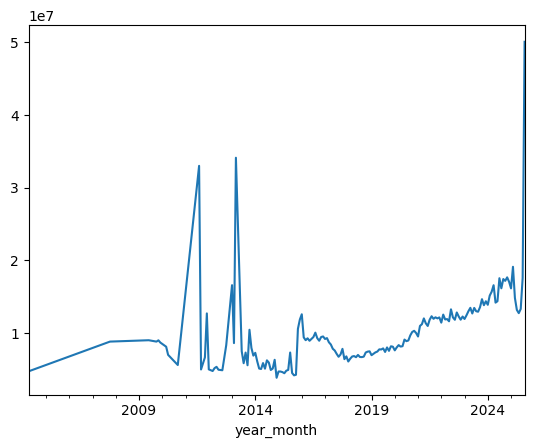

In [ ]:
df.groupby("year_month")["price"].mean().plot()

После нормализации:

Линия, то есть средняя цена за каждый месяц остается неизменной

<Axes: xlabel='year_month'>

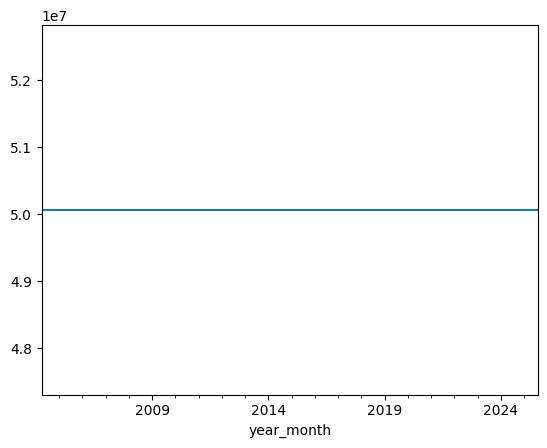

In [ ]:
df.groupby("year_month")["price_real"].mean().plot()

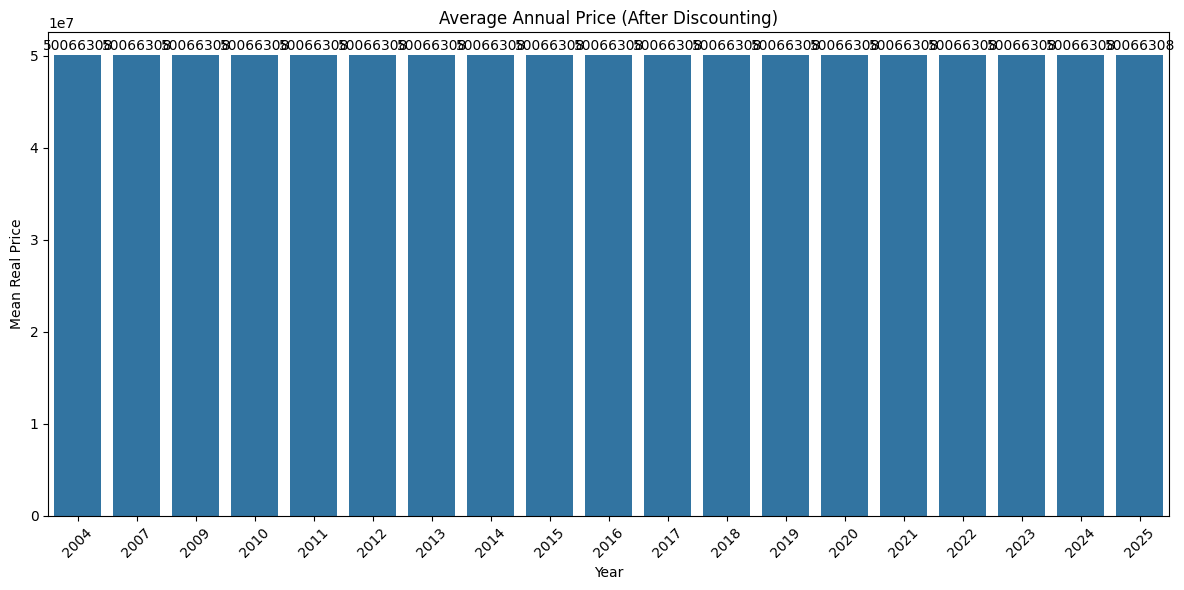

In [ ]:
plt.figure(figsize=(12, 6))

yearly_mean_real = df.groupby("year", as_index=False).agg(
    mean_price_real=("price_real", "mean")
)

ax = sns.barplot(data=yearly_mean_real, x="year", y="mean_price_real", color="#1f77b4")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Average Annual Price (After Discounting)")
plt.xlabel("Year")
plt.ylabel("Mean Real Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Далее просто идут графики сравнения реальных и номинальных цен.

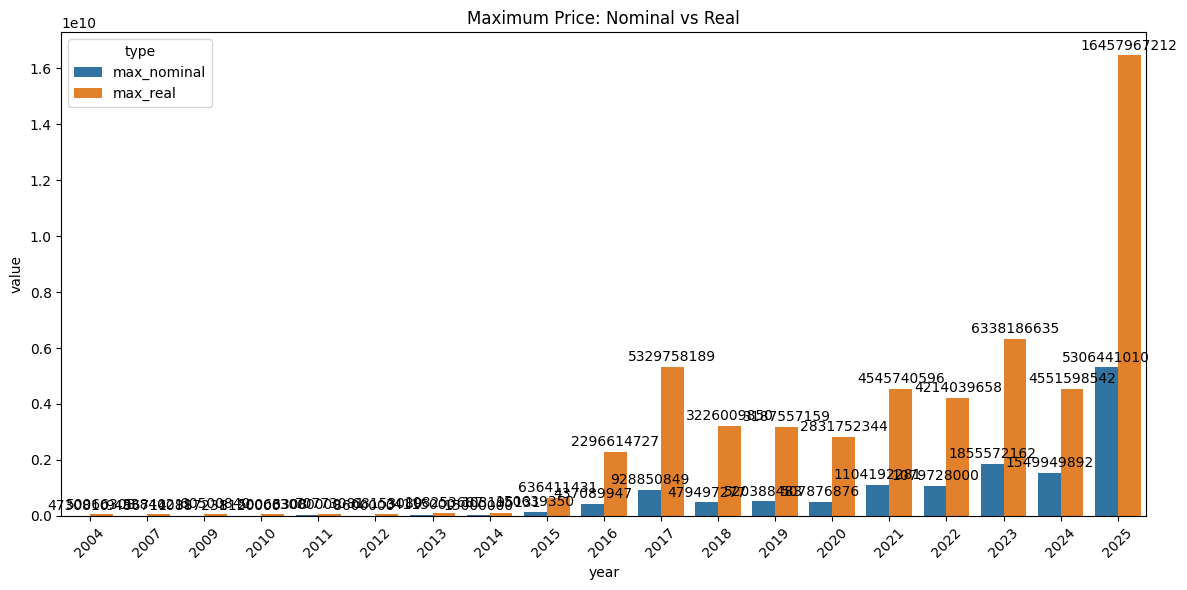

In [ ]:
yearly_max = df.groupby("year", as_index=False).agg(
    max_nominal=("price", "max"), max_real=("price_real", "max")
)

yearly_max_long = yearly_max.melt(
    id_vars="year",
    value_vars=["max_nominal", "max_real"],
    var_name="type",
    value_name="value",
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(data=yearly_max_long, x="year", y="value", hue="type")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Maximum Price: Nominal vs Real")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

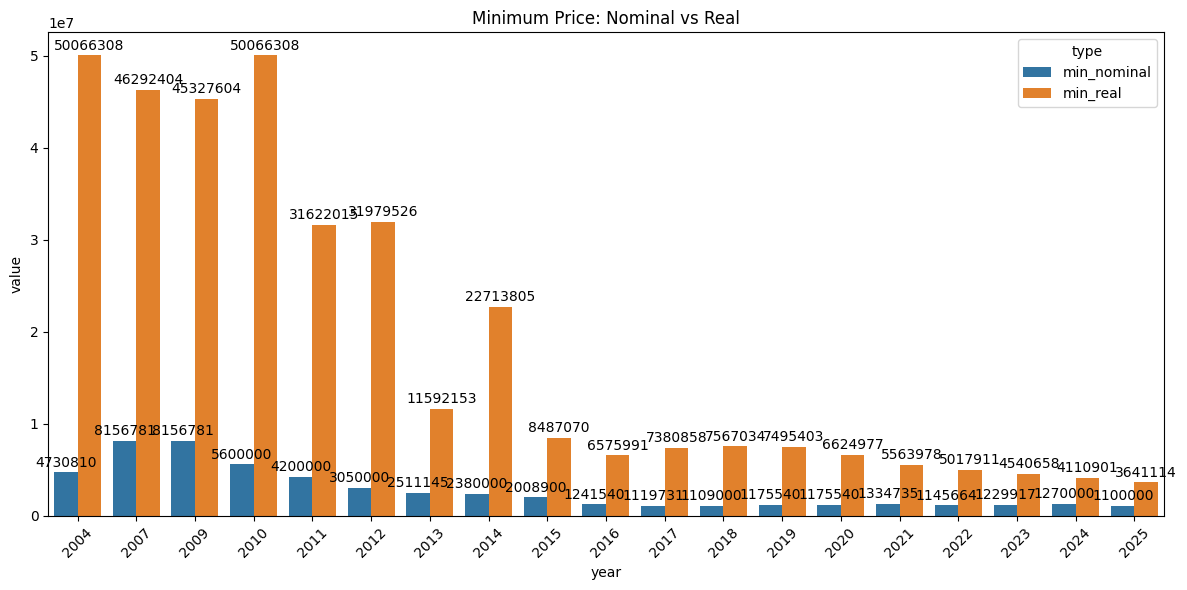

In [ ]:
yearly_min = df.groupby("year", as_index=False).agg(
    min_nominal=("price", "min"), min_real=("price_real", "min")
)

yearly_min_long = yearly_min.melt(
    id_vars="year",
    value_vars=["min_nominal", "min_real"],
    var_name="type",
    value_name="value",
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(data=yearly_min_long, x="year", y="value", hue="type")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Minimum Price: Nominal vs Real")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["ppsqm_real"] = df["price_per_square_meter"] / df["index"]

In [26]:
print("""
Изменения в датафрейме:

1. Добавлен столбец 'year_month' — период (год-месяц).
2. Добавлен столбец 'index' — индекс цен по месяцам.
3. Добавлен столбец 'price_real' — цена квартиры в постоянных ценах базового месяца.
4. Добавлен столбец 'ppsqm_real' — цена за м² в постоянных ценах.
""")


Изменения в датафрейме:

1. Добавлен столбец 'year_month' — период (год-месяц).
2. Добавлен столбец 'index' — индекс цен по месяцам.
3. Добавлен столбец 'price_real' — цена квартиры в постоянных ценах базового месяца.
4. Добавлен столбец 'ppsqm_real' — цена за м² в постоянных ценах.



In [ ]:
df[
    ["date", "price", "price_real", "price_per_square_meter", "ppsqm_real", "index"]
].head()

,date,price,price_real,price_per_square_meter,ppsqm_real,index
0,2025-06-09,"3,500,000.00","13,162,823.62","78,299.80","294,470.42",0.27
1,2025-05-21,"6,100,000.00","23,979,890.29","312,820.50","1,229,737.91",0.25
2,2025-05-06,"26,000,000.00","102,209,368.45","423,452.80","1,664,647.82",0.25
3,2025-05-21,"6,711,000.00","26,381,810.45","156,069.80","613,530.60",0.25
4,2025-06-10,"3,500,000.00","13,162,823.62","79,545.50","299,155.25",0.27


In [ ]:
comparison = df.groupby("year", as_index=False).agg(
    mean_nominal=("price", "mean"), mean_real=("price_real", "mean")
)

comparison.head()

,year,mean_nominal,mean_real
0,2004,"4,730,810.00","50,066,307.75"
1,2007,"8,821,747.45","50,066,307.75"
2,2009,"8,929,742.11","50,066,307.75"
3,2010,"6,906,666.67","50,066,307.75"
4,2011,"11,248,625.00","50,066,307.75"


In [ ]:
print("Std of yearly mean (nominal):", df.groupby("year")["price"].mean().std())

print("Std of yearly mean (real):", df.groupby("year")["price_real"].mean().std())

Std of yearly mean (nominal): 3158686.654411852
Std of yearly mean (real): 2.483526865641276e-09


In [ ]:
base_month = monthly_stats.loc[monthly_stats["index"] == 1, "year_month"]
print("Базовый период:", base_month.values)

Базовый период: [Period('2025-08', 'M')]


Сделаем аналогичное только для рынка первички и только для рынка вторички.

In [ ]:
monthly_by_mt = df.groupby(["year_month", "market_type"], as_index=False).agg(
    mean_price=("price", "mean"), mean_ppsqm=("price_per_square_meter", "mean")
)

monthly_by_mt = monthly_by_mt.sort_values(["market_type", "year_month"])
monthly_by_mt["base_mean_price"] = monthly_by_mt.groupby("market_type")[
    "mean_price"
].transform("last")
monthly_by_mt["base_mean_ppsqm"] = monthly_by_mt.groupby("market_type")[
    "mean_ppsqm"
].transform("last")

monthly_by_mt["index_price_mt"] = (
    monthly_by_mt["mean_price"] / monthly_by_mt["base_mean_price"]
)
monthly_by_mt["index_ppsqm_mt"] = (
    monthly_by_mt["mean_ppsqm"] / monthly_by_mt["base_mean_ppsqm"]
)

df = df.merge(
    monthly_by_mt[["year_month", "market_type", "index_price_mt", "index_ppsqm_mt"]],
    on=["year_month", "market_type"],
    how="left",
)

In [ ]:
df["price_real_primary"] = np.where(
    df["market_type"].eq("primary"), df["price"] / df["index_price_mt"], np.nan
)

df["price_real_secondary"] = np.where(
    df["market_type"].eq("secondary"), df["price"] / df["index_price_mt"], np.nan
)

df["ppsqm_real_primary"] = np.where(
    df["market_type"].eq("primary"),
    df["price_per_square_meter"] / df["index_ppsqm_mt"],
    np.nan,
)

df["ppsqm_real_secondary"] = np.where(
    df["market_type"].eq("secondary"),
    df["price_per_square_meter"] / df["index_ppsqm_mt"],
    np.nan,
)

In [ ]:
yearly_extremes = df.groupby("year", as_index=False).agg(
    max_primary=("price_real_primary", "max"),
    min_primary=("price_real_primary", "min"),
    max_secondary=("price_real_secondary", "max"),
    min_secondary=("price_real_secondary", "min"),
)

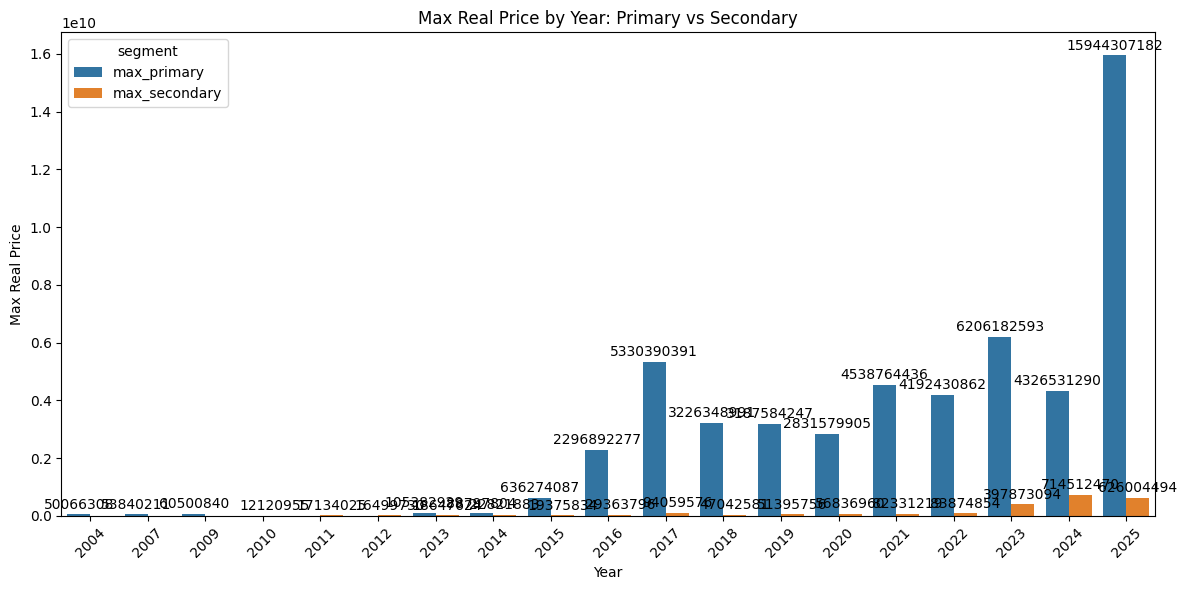

In [ ]:
max_long = yearly_extremes.melt(
    id_vars="year",
    value_vars=["max_primary", "max_secondary"],
    var_name="segment",
    value_name="max_real_price",
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=max_long, x="year", y="max_real_price", hue="segment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Max Real Price by Year: Primary vs Secondary")
plt.xlabel("Year")
plt.ylabel("Max Real Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

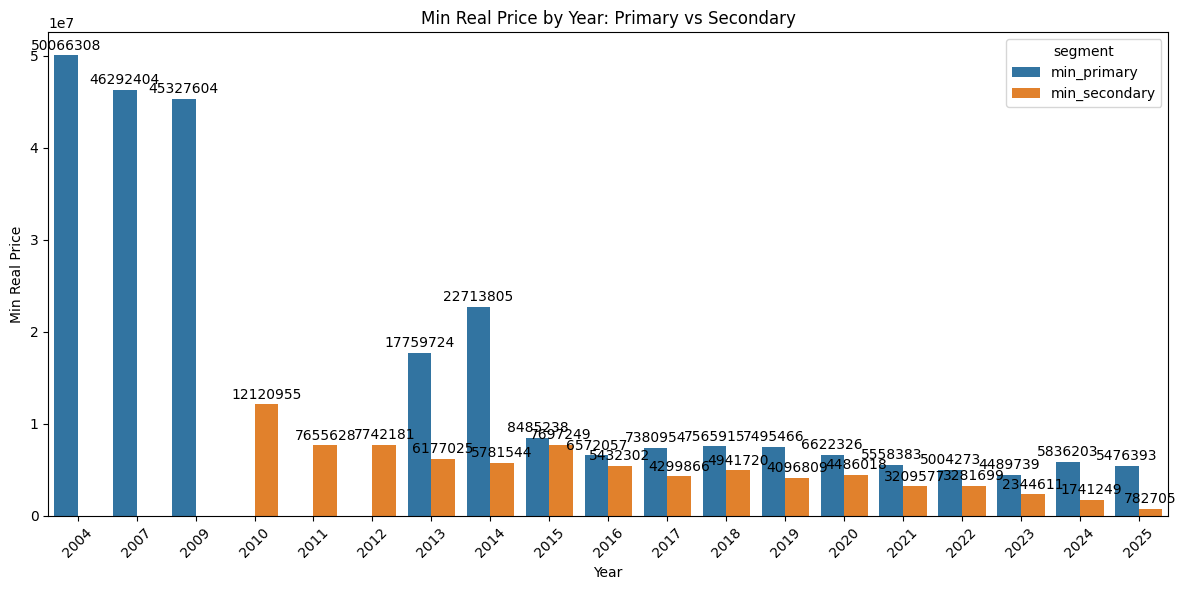

In [ ]:
min_long = yearly_extremes.melt(
    id_vars="year",
    value_vars=["min_primary", "min_secondary"],
    var_name="segment",
    value_name="min_real_price",
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=min_long, x="year", y="min_real_price", hue="segment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Min Real Price by Year: Primary vs Secondary")
plt.xlabel("Year")
plt.ylabel("Min Real Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()